In [44]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split   
from sklearn import metrics
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
## Importin data 
data = pd.read_csv("data.csv")

In [46]:
data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [47]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [48]:
data.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [49]:
data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


Positive Corr 
Negative Corr

In [50]:
correlation = data.drop('Date', axis=1).corr()

<Axes: >

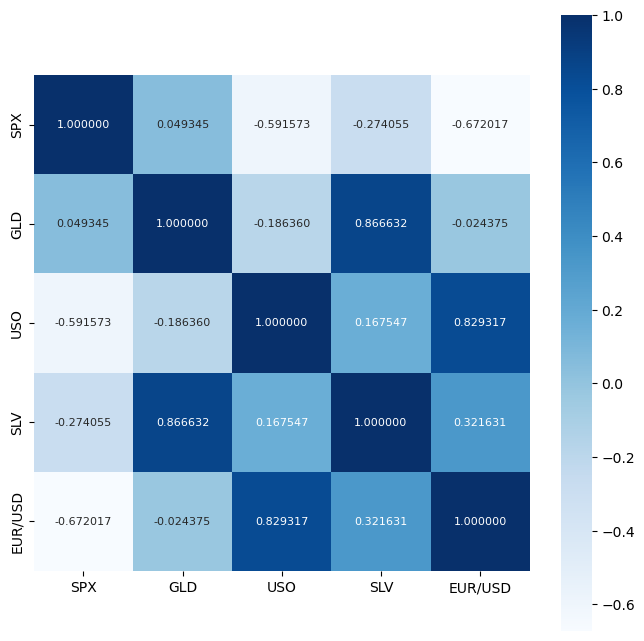

In [51]:
plt.figure(figsize=(8,8) )
sns.heatmap(correlation,cbar=True,square=True,fmt='1f',annot=True,annot_kws={'size': 8}, cmap="Blues")

In [52]:
print(correlation['GLD'])

SPX        0.049345
GLD        1.000000
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
Name: GLD, dtype: float64


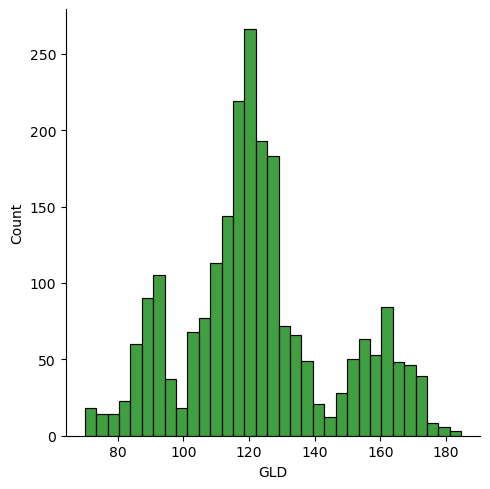

In [53]:
sns.displot(data['GLD'],color = "green")

Splitting the data in X and Y

In [54]:
X = data.drop(columns=['Date','GLD'],axis=1)
Y = data['GLD']

In [55]:
print(X.shape)
print(Y.shape)

(2290, 4)
(2290,)


Splitting into Training and testing 

In [57]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

Model Training 

In [58]:
model = RandomForestRegressor()

In [59]:
model.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
## Prediction adn evaluation    
Train_pred = model.predict(X_train)

train_score = metrics.r2_score(Y_train,Train_pred)

print(f"The r2 score of the Traning data is {train_score}")

The r2 score of the Traning data is 0.9986369480326927


In [61]:
## Prediction and model evaluation in testing data
Test_pred = model.predict(X_test)

test_score = metrics.r2_score(Y_test,Test_pred)

print(f"The r2score of the Testing Data is {test_score}")

The r2score of the Testing Data is 0.9909306586305499


Compare the true value and pedicted value

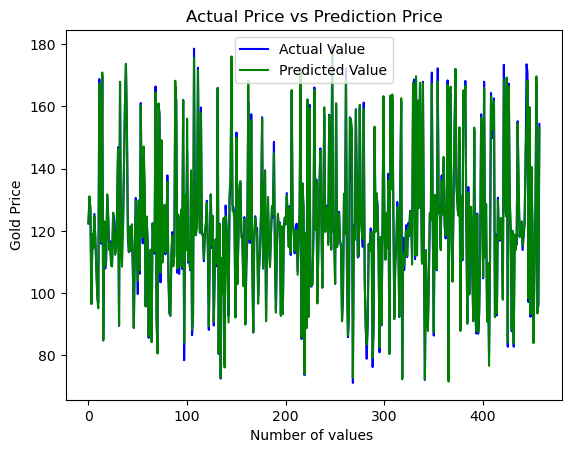

In [62]:
Y_test = list(Y_test)

plt.plot(Y_test, color = 'blue', label = "Actual Value")
plt.plot(Test_pred, color = 'green', label = "Predicted Value")
plt.title("Actual Price vs Prediction Price")
plt.xlabel("Number of values ")
plt.ylabel("Gold Price")
plt.legend()
plt.show()